# 1qb-DB V4 — per-experiment canonical / vz-free switch

> **CSV routing card for the experimenter (read this before running anything).**
>
> Delivery root: `proposals/Novera_work/delivery_1GSa/`

For each `(arm, unit)` we simulate both the canonical and vz-free delivery files at
$\epsilon\in\{0,2\%\}$ and define

$$
\mathrm{score}=\max\left[\operatorname{ptp}(P_+|_{\epsilon=0}),
\operatorname{ptp}(P_+|_{\epsilon=2\%})\right].
$$

The selected file is the variant with the smaller score. If the scores differ by at
most $10^{-9}$, the tie is resolved in favour of **canonical**. **Selecting the smaller
score does not guarantee a flat trace**: it only chooses the less oscillatory of the
two supplied variants. In particular, arm A's `YY` and `XXb` traces remain strongly
oscillatory even though canonical wins the tie / near-tie.

`XXb` uses the selected X waveform for that unit: first $X$, then the same waveform
with the complete control Hamiltonian negated (the bare Hamiltonian is not negated).

| arm | `XX` file | `YY` file | `XXb` file |
|---|---|---|---|
| A | canonical — `Xpi/waveforms/Xpi_novera_A_gaussian.csv` | canonical — `Ypi/waveforms/Ypi_novera_A_gaussian.csv` | canonical — `Xpi/waveforms/Xpi_novera_A_gaussian.csv` |
| B | vz-free — `Xpi/waveforms/Xpi_novera_B_gaussian_drag_vzfree.csv` | canonical — `Ypi/waveforms/Ypi_novera_B_gaussian_drag.csv` | canonical — `Xpi/waveforms/Xpi_novera_B_gaussian_drag.csv` |
| C | vz-free — `Xpi/waveforms/Xpi_novera_C_optimized_vzfree.csv` | canonical — `Ypi/waveforms/Ypi_novera_C_optimized.csv` | canonical — `Xpi/waveforms/Xpi_novera_C_optimized.csv` |
| D | vz-free — `Xpi/waveforms/Xpi_novera_D_optimized_fluence_cap_vzfree.csv` | canonical — `Ypi/waveforms/Ypi_novera_D_optimized_fluence_cap.csv` | canonical — `Xpi/waveforms/Xpi_novera_D_optimized_fluence_cap.csv` |
| E | vz-free — `Xpi/waveforms/Xpi_novera_E_optimized_ad_exact_vzfree.csv` | canonical — `Ypi/waveforms/Ypi_novera_E_optimized_ad_exact.csv` | canonical — `Xpi/waveforms/Xpi_novera_E_optimized_ad_exact.csv` |
| F | vz-free — `Xpi/waveforms/Xpi_novera_F_optimized_ad_robust_vzfree.csv` | canonical — `Ypi/waveforms/Ypi_novera_F_optimized_ad_robust.csv` | canonical — `Xpi/waveforms/Xpi_novera_F_optimized_ad_robust.csv` |

This notebook performs coherent three-level, 1 GSa/s sample-and-hold propagation.
Preparation and readout are $|+x\rangle=(|0\rangle+|1\rangle)/\sqrt2$. It adds no
optimisation, calibration, detuning, dissipation, SPAM, or hardware-transfer model.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import expm


def find_repo_root(start=None):
    """Find the repository from any usual notebook working directory."""
    start = Path.cwd() if start is None else Path(start)
    marker = Path("proposals/Novera_work/delivery_1GSa/delivery_metadata.json")
    for candidate in (start, *start.parents):
        if (candidate / marker).is_file():
            return candidate
    raise FileNotFoundError(
        f"Could not find {marker} above current working directory {start}. "
        "Open this notebook from inside the curve_optimize_tool repository."
    )


REPO_ROOT = find_repo_root()
DELIVERY_RELATIVE = Path("proposals/Novera_work/delivery_1GSa")
DELIVERY_DIR = REPO_ROOT / DELIVERY_RELATIVE
METADATA_PATH = DELIVERY_DIR / "delivery_metadata.json"
assert METADATA_PATH.is_file(), f"Missing delivery metadata: {METADATA_PATH}"
with METADATA_PATH.open() as stream:
    DELIVERY = json.load(stream)

DEVICE = DELIVERY["device"]
ARMS = tuple(DELIVERY["gates"]["Xpi"]["arms"])
assert ARMS == tuple("ABCDEF"), f"Expected A–F delivery arms, found {ARMS}"
print(
    f"Loaded {DELIVERY['package']}: arms {', '.join(ARMS)}, "
    f"T = {DEVICE['gate_time_ns']:g} ns at {DEVICE['sample_rate_GSa']:g} GSa/s"
)

Matplotlib is building the font cache; this may take a moment.


Loaded Novera single-qubit pi-gate waveform delivery: arms A, B, C, D, E, F, T = 50 ns at 1 GSa/s


## Load both candidates and enforce the routing card

Both canonical and vz-free files are required and loaded for every X/Y arm. `ROUTING`
is the explicit per-unit selection used by all chosen traces and plots. The exact
selected relative paths are printed at runtime and checked against the routing card
above.

In [2]:
UNIT_ORDER = ("XX", "YY", "XXb")
VARIANTS = ("canonical", "vzfree")
UNIT_GATE = {"XX": "Xpi", "YY": "Ypi", "XXb": "Xpi"}

ROUTING = {
    "A": {"XX": "canonical", "YY": "canonical", "XXb": "canonical"},
    "B": {"XX": "vzfree", "YY": "canonical", "XXb": "canonical"},
    "C": {"XX": "vzfree", "YY": "canonical", "XXb": "canonical"},
    "D": {"XX": "vzfree", "YY": "canonical", "XXb": "canonical"},
    "E": {"XX": "vzfree", "YY": "canonical", "XXb": "canonical"},
    "F": {"XX": "vzfree", "YY": "canonical", "XXb": "canonical"},
}

# Literal paths mirror the opening Markdown routing card and guard against metadata
# or routing edits silently changing the files handed to the experimenter.
EXPECTED_SELECTED_RELATIVE_PATHS = {
    "A": {
        "XX": "Xpi/waveforms/Xpi_novera_A_gaussian.csv",
        "YY": "Ypi/waveforms/Ypi_novera_A_gaussian.csv",
        "XXb": "Xpi/waveforms/Xpi_novera_A_gaussian.csv",
    },
    "B": {
        "XX": "Xpi/waveforms/Xpi_novera_B_gaussian_drag_vzfree.csv",
        "YY": "Ypi/waveforms/Ypi_novera_B_gaussian_drag.csv",
        "XXb": "Xpi/waveforms/Xpi_novera_B_gaussian_drag.csv",
    },
    "C": {
        "XX": "Xpi/waveforms/Xpi_novera_C_optimized_vzfree.csv",
        "YY": "Ypi/waveforms/Ypi_novera_C_optimized.csv",
        "XXb": "Xpi/waveforms/Xpi_novera_C_optimized.csv",
    },
    "D": {
        "XX": "Xpi/waveforms/Xpi_novera_D_optimized_fluence_cap_vzfree.csv",
        "YY": "Ypi/waveforms/Ypi_novera_D_optimized_fluence_cap.csv",
        "XXb": "Xpi/waveforms/Xpi_novera_D_optimized_fluence_cap.csv",
    },
    "E": {
        "XX": "Xpi/waveforms/Xpi_novera_E_optimized_ad_exact_vzfree.csv",
        "YY": "Ypi/waveforms/Ypi_novera_E_optimized_ad_exact.csv",
        "XXb": "Xpi/waveforms/Xpi_novera_E_optimized_ad_exact.csv",
    },
    "F": {
        "XX": "Xpi/waveforms/Xpi_novera_F_optimized_ad_robust_vzfree.csv",
        "YY": "Ypi/waveforms/Ypi_novera_F_optimized_ad_robust.csv",
        "XXb": "Xpi/waveforms/Xpi_novera_F_optimized_ad_robust.csv",
    },
}


def read_waveform_csv(path, entry):
    """Read a delivery CSV with its long '#' header explicitly skipped."""
    columns, rows = None, []
    with Path(path).open() as stream:
        for raw_line in stream:
            line = raw_line.strip()
            if not line or line.startswith("#"):
                continue
            if columns is None:
                columns = [column.strip() for column in line.split(",")]
                assert columns and all(columns), f"Invalid CSV header in {path}"
                assert len(columns) == len(set(columns)), f"Duplicate CSV columns in {path}"
                continue
            values = [value.strip() for value in line.split(",")]
            assert len(values) == len(columns), (
                f"Column count mismatch in {path}: expected {len(columns)}, "
                f"got {len(values)} for row {line!r}"
            )
            try:
                rows.append([float(value) for value in values])
            except ValueError as exc:
                raise AssertionError(f"Non-numeric data row in {path}: {line!r}") from exc

    assert columns is not None, f"No non-comment CSV header found in {path}"
    assert rows, f"No numeric data rows found in {path}"
    array = np.asarray(rows, dtype=float)
    assert array.ndim == 2 and array.shape[1] == len(columns), (path, array.shape, columns)
    data = dict(zip(columns, array.T))
    needed = {"t_ns", "Omega_x_rad_per_ns", "Omega_y_rad_per_ns"}
    assert needed <= set(data), f"Missing {needed - set(data)} in {path}"

    time = np.asarray(data["t_ns"], dtype=float)
    assert len(time) == entry["n_samples"], (path, len(time), entry["n_samples"])
    assert np.allclose(np.diff(time), entry["dt_ns"]), (path, "time grid does not match metadata")
    return {
        "t_ns": time,
        "omega_x": np.asarray(data["Omega_x_rad_per_ns"], dtype=float),
        "omega_y": np.asarray(data["Omega_y_rad_per_ns"], dtype=float),
        "dt_ns": float(entry["dt_ns"]),
        "path": Path(path),
    }


def load_waveform_candidates(delivery, delivery_dir):
    candidates, files = {}, {}
    reference_time = None
    for gate_name in ("Xpi", "Ypi"):
        candidates[gate_name], files[gate_name] = {}, {}
        gate_arms = delivery["gates"][gate_name]["arms"]
        assert tuple(gate_arms) == ARMS, f"{gate_name} arm keys disagree with Xpi"
        for arm in ARMS:
            entry = gate_arms[arm]
            paths = {
                "canonical": delivery_dir / gate_name / entry["csv"],
                "vzfree": delivery_dir / gate_name / entry["csv_vzfree"],
            }
            for variant, path in paths.items():
                assert path.is_file(), f"Missing {variant} CSV: {path}"
            loaded = {variant: read_waveform_csv(path, entry) for variant, path in paths.items()}
            for waveform in loaded.values():
                time = waveform["t_ns"]
                if reference_time is None:
                    reference_time = time
                else:
                    assert np.allclose(time, reference_time), (arm, gate_name, "time grid mismatch")
            candidates[gate_name][arm] = loaded
            files[gate_name][arm] = paths
    return candidates, files


CANDIDATES, WAVEFORM_FILES = load_waveform_candidates(DELIVERY, DELIVERY_DIR)
SELECTED = {arm: {} for arm in ARMS}
print("Selected CSV paths (relative to proposals/Novera_work/delivery_1GSa/):")
for arm in ARMS:
    assert set(ROUTING[arm]) == set(UNIT_ORDER)
    for unit in UNIT_ORDER:
        variant = ROUTING[arm][unit]
        gate_name = UNIT_GATE[unit]
        waveform = CANDIDATES[gate_name][arm][variant]
        relative_path = waveform["path"].relative_to(DELIVERY_DIR).as_posix()
        assert relative_path == EXPECTED_SELECTED_RELATIVE_PATHS[arm][unit], (
            arm, unit, relative_path, EXPECTED_SELECTED_RELATIVE_PATHS[arm][unit]
        )
        SELECTED[arm][unit] = waveform
        print(f"  {arm} {unit:3s}: {variant:9s}  {relative_path}")

Selected CSV paths (relative to proposals/Novera_work/delivery_1GSa/):
  A XX : canonical  Xpi/waveforms/Xpi_novera_A_gaussian.csv
  A YY : canonical  Ypi/waveforms/Ypi_novera_A_gaussian.csv
  A XXb: canonical  Xpi/waveforms/Xpi_novera_A_gaussian.csv
  B XX : vzfree     Xpi/waveforms/Xpi_novera_B_gaussian_drag_vzfree.csv
  B YY : canonical  Ypi/waveforms/Ypi_novera_B_gaussian_drag.csv
  B XXb: canonical  Xpi/waveforms/Xpi_novera_B_gaussian_drag.csv
  C XX : vzfree     Xpi/waveforms/Xpi_novera_C_optimized_vzfree.csv
  C YY : canonical  Ypi/waveforms/Ypi_novera_C_optimized.csv
  C XXb: canonical  Xpi/waveforms/Xpi_novera_C_optimized.csv
  D XX : vzfree     Xpi/waveforms/Xpi_novera_D_optimized_fluence_cap_vzfree.csv
  D YY : canonical  Ypi/waveforms/Ypi_novera_D_optimized_fluence_cap.csv
  D XXb: canonical  Xpi/waveforms/Xpi_novera_D_optimized_fluence_cap.csv
  E XX : vzfree     Xpi/waveforms/Xpi_novera_E_optimized_ad_exact_vzfree.csv
  E YY : canonical  Ypi/waveforms/Ypi_novera_E_optimiz

## Selected played waveforms, one panel per experiment

Every panel below is the actual waveform selected for that `(arm, unit)`. The title
shows `canonical` or `vz-free`; `XXb` displays the selected X waveform before the
control-sign reversal used to construct $X_b$.

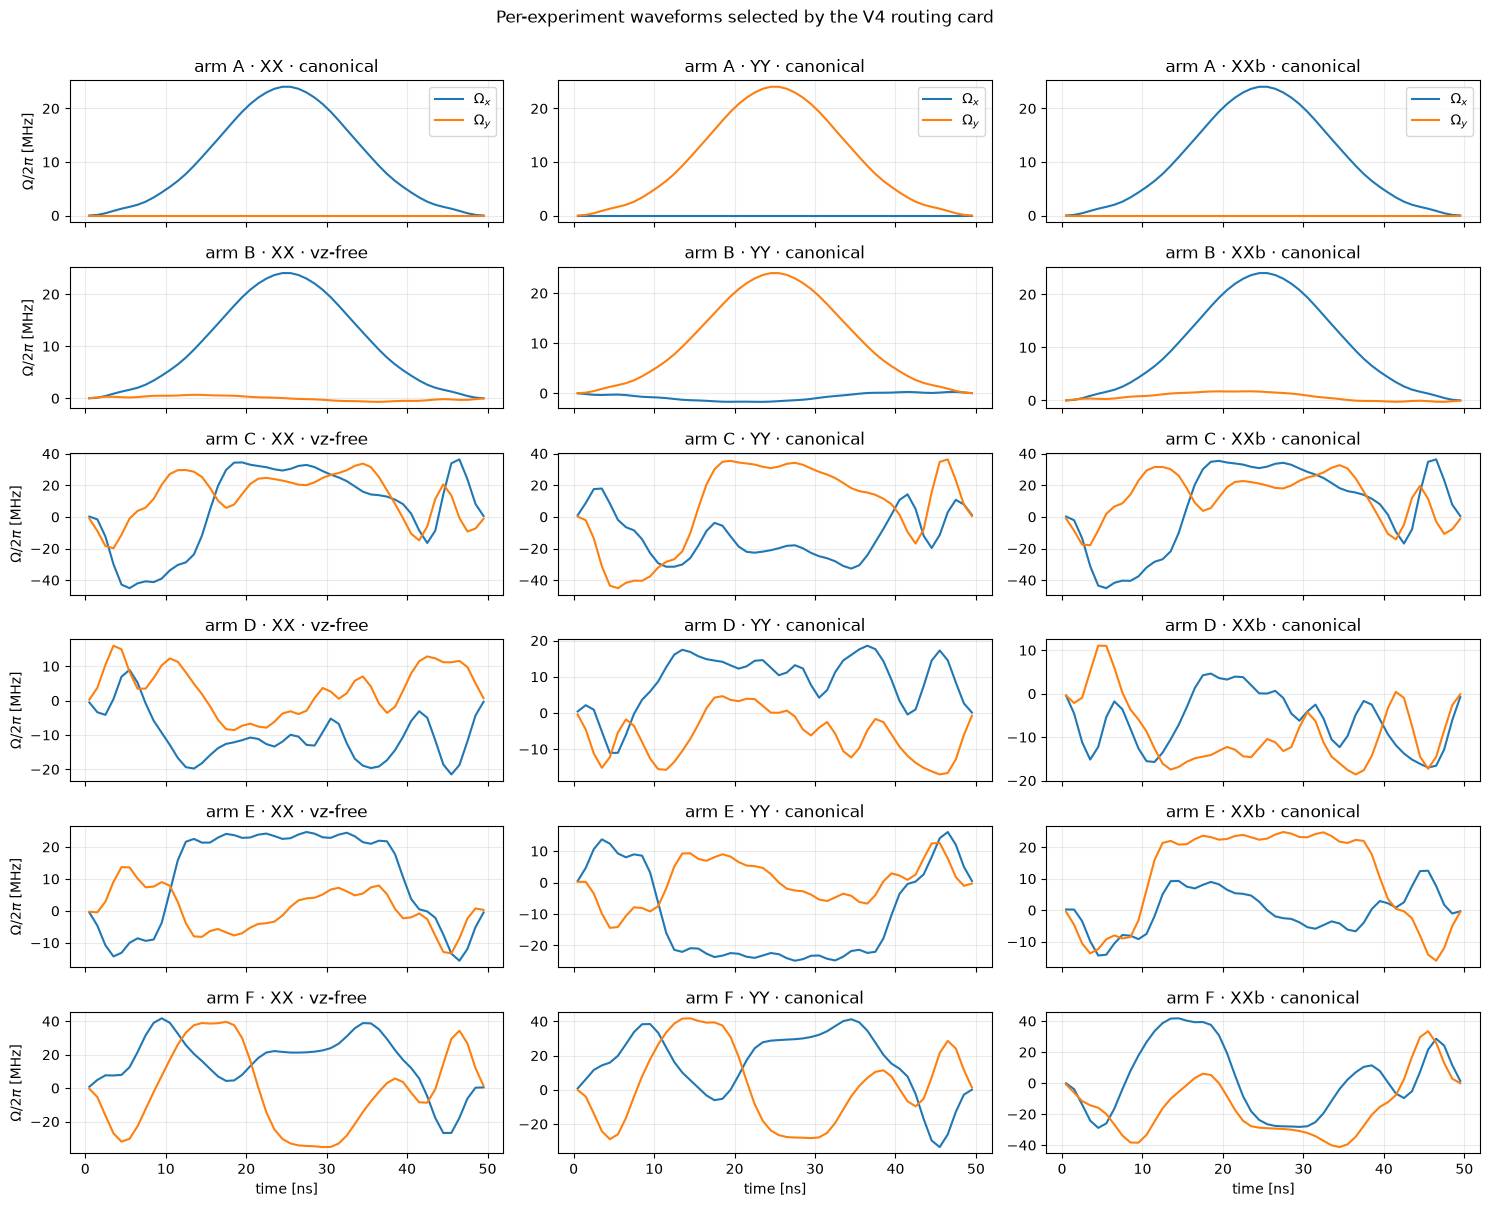

In [3]:
fig, axes = plt.subplots(len(ARMS), len(UNIT_ORDER), figsize=(15, 2.0 * len(ARMS)), sharex=True)
for row, arm in enumerate(ARMS):
    for col, unit in enumerate(UNIT_ORDER):
        waveform = SELECTED[arm][unit]
        variant_label = "vz-free" if ROUTING[arm][unit] == "vzfree" else "canonical"
        axis = axes[row, col]
        axis.plot(waveform["t_ns"], waveform["omega_x"] / (2 * np.pi) * 1e3, label=r"$\Omega_x$")
        axis.plot(waveform["t_ns"], waveform["omega_y"] / (2 * np.pi) * 1e3, label=r"$\Omega_y$")
        axis.set_title(f"arm {arm} · {unit} · {variant_label}")
        axis.grid(alpha=0.25)
        if row == 0:
            axis.legend(loc="upper right")
        if col == 0:
            axis.set_ylabel(r"$\Omega/2\pi$ [MHz]")
        if row == len(ARMS) - 1:
            axis.set_xlabel("time [ns]")
fig.suptitle("Per-experiment waveforms selected by the V4 routing card", y=1.002)
fig.tight_layout()
plt.show()

## DB experiment definition

For each arm, prepare $|+x\rangle$ and repeat one unit cell $n=0,\ldots,N$ times:

1. `XX`: $U_XU_X$.
2. `YY`: $U_YU_Y$.
3. `XXb`: first $X$, then $X_b$, hence $U_{X_b}U_X$.

$X_b$ reverses the **complete control Hamiltonian**,
$H_c(t)\mapsto-(1+\epsilon)H_c(t)$, while the bare three-level anharmonicity is
unchanged. This is the same `XXb` definition as V2/V3 and is retained here only to
test CSV routing; it is not claimed as an independent validation of the paper's
inverse-gate protocol.

In [4]:
# Deliberate control-error setting and sequence length; edit these two experiment knobs only.
INJECTED_ERROR = 0.02
N_REPEATS = 100
ERROR_LEVELS = (0.0, INJECTED_ERROR)

# Device quantities are read from delivery_metadata.json, never duplicated as notebook constants.
DELTA = 2 * np.pi * float(DEVICE["anharmonicity_GHz"])
a = np.array([[0, 1, 0], [0, 0, np.sqrt(2)], [0, 0, 0]], dtype=complex)
DX = 0.5 * (a + a.conj().T)
DY = 0.5j * (a.conj().T - a)
H_BARE = np.diag([0.0, 0.0, DELTA]).astype(complex)
PLUS = np.array([1.0, 1.0, 0.0], dtype=complex) / np.sqrt(2)


def gate_propagator(waveform, epsilon, control_sign=1.0):
    """Three-level midpoint/sample-and-hold propagator for one delivered gate."""
    unitary = np.eye(3, dtype=complex)
    for omega_x, omega_y in zip(waveform["omega_x"], waveform["omega_y"]):
        h_control = control_sign * (1.0 + epsilon) * (omega_x * DX + omega_y * DY)
        step = expm(-1j * (H_BARE + h_control) * waveform["dt_ns"])
        unitary = step @ unitary  # newest sample-and-hold step is on the left
    return unitary


def db_trace(unit_cell, repeats=N_REPEATS):
    """Pure-state DB trace: repeat one unit cell and read only P_plus."""
    psi = PLUS.copy()
    p_plus = np.empty(repeats + 1)
    p_plus[0] = abs(np.vdot(PLUS, psi)) ** 2
    for repeat in range(repeats):
        psi = unit_cell @ psi
        p_plus[repeat + 1] = abs(np.vdot(PLUS, psi)) ** 2
    return p_plus


def traces_for_variant(arm, variant):
    """Compute XX, YY and XXb traces from one candidate variant."""
    traces = {unit: {} for unit in UNIT_ORDER}
    x_waveform = CANDIDATES["Xpi"][arm][variant]
    y_waveform = CANDIDATES["Ypi"][arm][variant]
    for epsilon in ERROR_LEVELS:
        ux = gate_propagator(x_waveform, epsilon, control_sign=+1.0)
        uy = gate_propagator(y_waveform, epsilon, control_sign=+1.0)
        uxb = gate_propagator(x_waveform, epsilon, control_sign=-1.0)
        unit_cells = {
            "XX": ux @ ux,
            "YY": uy @ uy,
            "XXb": uxb @ ux,  # first X, then Xb
        }
        for unit, unit_cell in unit_cells.items():
            traces[unit][epsilon] = db_trace(unit_cell)
    return traces


VARIANT_TRACES = {
    arm: {variant: traces_for_variant(arm, variant) for variant in VARIANTS}
    for arm in ARMS
}
TRACES = {
    arm: {
        unit: VARIANT_TRACES[arm][ROUTING[arm][unit]][unit]
        for unit in UNIT_ORDER
    }
    for arm in ARMS
}
assert sum(len(TRACES[arm][unit]) for arm in ARMS for unit in UNIT_ORDER) == 6 * 3 * 2
print(f"Prepared {6 * 3 * 2} selected P_plus traces: 6 arms × 3 unit cells × 2 error settings.")

Prepared 36 selected P_plus traces: 6 arms × 3 unit cells × 2 error settings.


## Selected DB traces: $P_+$ versus repeated unit cells

One subplot is shown per arm. Colour identifies `XX`, `YY`, or `XXb`; dashed lines
are the no-injection reference and solid lines use the injected amplitude error.
Each unit uses its independently routed CSV variant from the opening card.

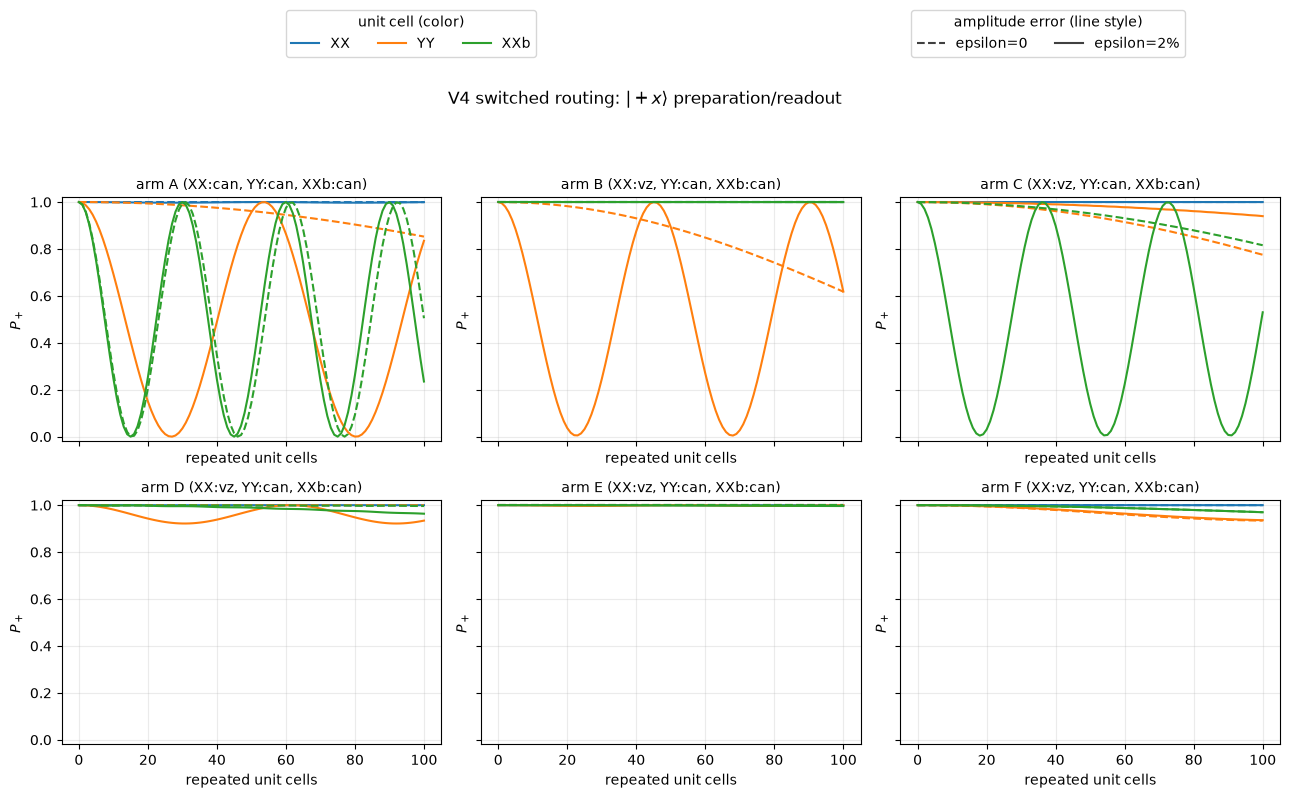

In [5]:
from matplotlib.lines import Line2D

repeats = np.arange(N_REPEATS + 1)
UNIT_COLORS = {"XX": "tab:blue", "YY": "tab:orange", "XXb": "tab:green"}
fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharex=True, sharey=True)
for axis, arm in zip(axes.flat, ARMS):
    for unit in UNIT_ORDER:
        color = UNIT_COLORS[unit]
        axis.plot(repeats, TRACES[arm][unit][0.0], "--", color=color)
        axis.plot(repeats, TRACES[arm][unit][INJECTED_ERROR], "-", color=color)
    route_summary = ", ".join(
        f"{unit}:{'vz' if ROUTING[arm][unit] == 'vzfree' else 'can'}" for unit in UNIT_ORDER
    )
    axis.set_title(f"arm {arm} ({route_summary})", fontsize=10)
    axis.set_xlabel("repeated unit cells")
    axis.set_ylabel(r"$P_+$")
    axis.set_ylim(-0.02, 1.02)
    axis.grid(alpha=0.25)

unit_handles = [Line2D([], [], color=UNIT_COLORS[name], label=name) for name in UNIT_ORDER]
error_handles = [
    Line2D([], [], color="0.25", linestyle="--", label="epsilon=0"),
    Line2D([], [], color="0.25", linestyle="-", label=f"epsilon={INJECTED_ERROR:.0%}"),
]
fig.legend(unit_handles, [handle.get_label() for handle in unit_handles], title="unit cell (color)",
           loc="upper center", bbox_to_anchor=(0.32, 1.00), ncol=3)
fig.legend(error_handles, [handle.get_label() for handle in error_handles], title="amplitude error (line style)",
           loc="upper center", bbox_to_anchor=(0.81, 1.00), ncol=2)
fig.suptitle(r"V4 switched routing: $|+x\rangle$ preparation/readout", y=0.89)
fig.tight_layout(rect=(0, 0, 1, 0.84))
plt.show()

## Selection audit

The audit recomputes each candidate's score from the traces above. It prints the
selected and alternative scores for all 18 `(arm, unit)` cases, independently derives
the minimum-score choice with the stated $10^{-9}$ canonical tie rule, and asserts
that both the static route and the inequality
`chosen_score <= alternative_score + 1e-9` hold.

In [6]:
SCORE_TIE_TOL = 1e-9


def trace_score(traces):
    """Largest peak-to-peak P_plus range across the two error settings."""
    return max(float(np.ptp(traces[epsilon])) for epsilon in ERROR_LEVELS)


AUDIT = {arm: {} for arm in ARMS}
print("Selection audit: score = max[ptp(epsilon=0), ptp(epsilon=2%)]")
for arm in ARMS:
    for unit in UNIT_ORDER:
        scores = {
            variant: trace_score(VARIANT_TRACES[arm][variant][unit])
            for variant in VARIANTS
        }
        chosen = ROUTING[arm][unit]
        alternative = "vzfree" if chosen == "canonical" else "canonical"
        if abs(scores["canonical"] - scores["vzfree"]) <= SCORE_TIE_TOL:
            derived_choice = "canonical"
        else:
            derived_choice = min(scores, key=scores.get)
        assert derived_choice == chosen, (arm, unit, scores, derived_choice, chosen)
        assert scores[chosen] <= scores[alternative] + SCORE_TIE_TOL, (arm, unit, scores)
        AUDIT[arm][unit] = {"chosen": chosen, "alternative": alternative, "scores": scores}
        print(
            f"  {arm} {unit:3s}: chosen {chosen:9s} {scores[chosen]:.12e} | "
            f"alternative {alternative:9s} {scores[alternative]:.12e}"
        )
print("All 18 static routes satisfy the score rule and tolerance.")

Selection audit: score = max[ptp(epsilon=0), ptp(epsilon=2%)]
  A XX : chosen canonical 2.752947582031e-03 | alternative vzfree    2.752947582038e-03
  A YY : chosen canonical 9.998399896657e-01 | alternative vzfree    9.998399896657e-01
  A XXb: chosen canonical 9.999931682794e-01 | alternative vzfree    9.999931682794e-01
  B XX : chosen vzfree    2.082620598198e-08 | alternative canonical 4.580643890208e-03
  B YY : chosen canonical 9.952173560396e-01 | alternative vzfree    9.997979912100e-01
  B XXb: chosen canonical 3.392563211752e-04 | alternative vzfree    3.408310232463e-04
  C XX : chosen vzfree    1.238415006060e-04 | alternative canonical 9.454712636852e-04
  C YY : chosen canonical 2.247129545228e-01 | alternative vzfree    2.256584129886e-01
  C XXb: chosen canonical 9.954066647190e-01 | alternative vzfree    9.998824433889e-01
  D XX : chosen vzfree    2.505545108799e-04 | alternative canonical 9.217819414172e-01
  D YY : chosen canonical 7.823299662972e-02 | alternative

## Reading the result

Compare solid and dashed curves within one arm/unit. Their separation is the response
to the injected amplitude error in this coherent three-level model. The routing
selection minimises the **absolute peak-to-peak oscillation** over both traces, not
their separation and not gate infidelity. Consequently, a selected trace may still
oscillate strongly; the opening routing card is an operational CSV-selection guide,
not a claim that every experiment becomes flat.